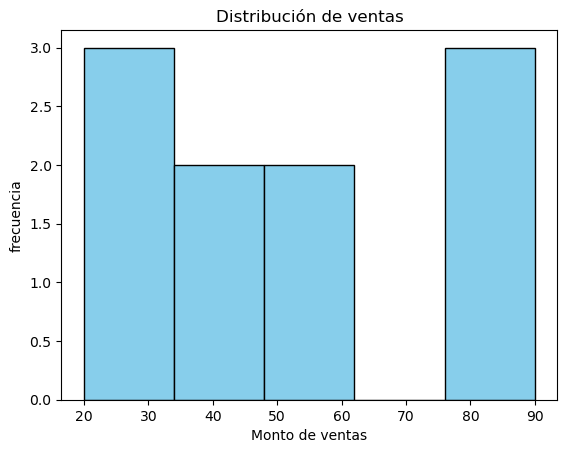

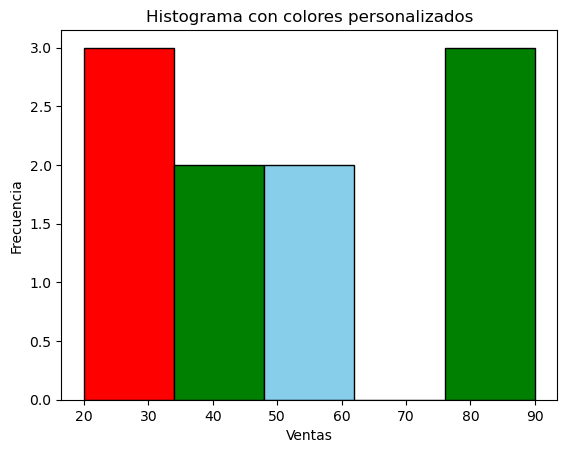

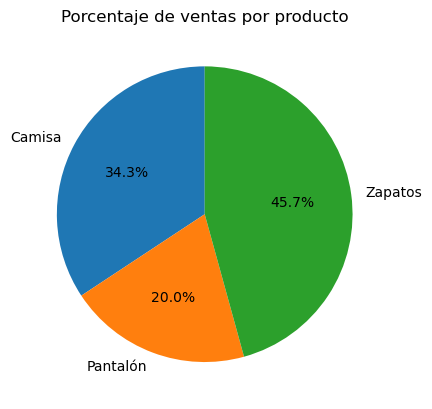

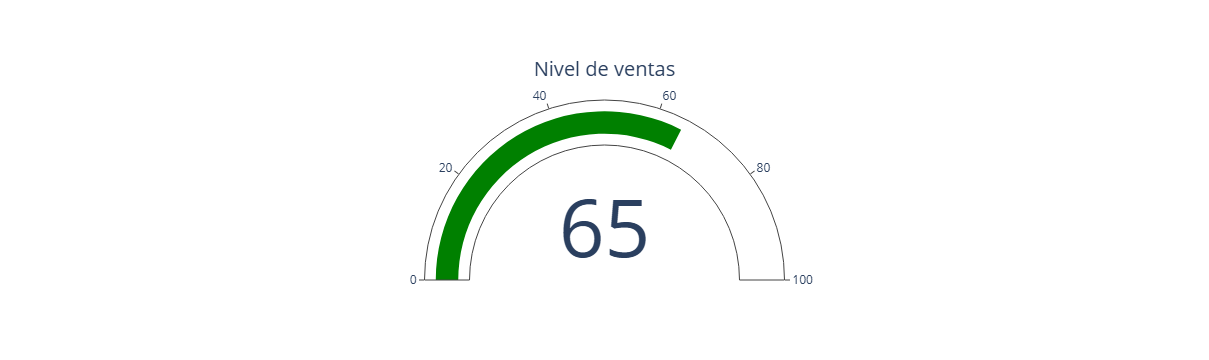

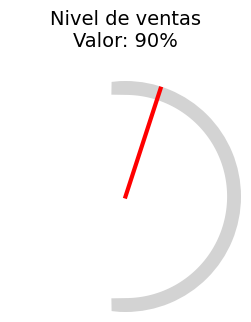

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.graph_objects as go

#datos por mes
data = {
    "Producto": ['Camisa','Zapatos','Pantalón','Camisa','Zapatos','Camisa','Pantalón','Camisa','Zapatos','Zapatos'],
    "Ventas": [25,80,45,30,90,40,60,85,20,50]
}


df = pd.DataFrame(data)

plt.hist(df['Ventas'], bins = 5, color ='skyblue', edgecolor = 'black')
plt.title('Distribución de ventas')
plt.xlabel('Monto de ventas')
plt.ylabel('frecuencia')
plt.show()


#colores dinámicos
colores = []

for v in df['Ventas']:
    if v < 30:
        colores.append('red')
    elif v > 70:
        colores.append('green')
    else:
        colores.append('skyblue')

# Calcula los bins y frecuencias
counts, bins = np.histogram(df['Ventas'], bins=5)

# Dibuja cada barra con su color
for i in range(len(counts)):
    plt.bar(bins[i], counts[i], width=bins[i+1]-bins[i], 
            color=colores[i], edgecolor='black', align='edge')

plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.title('Histograma con colores personalizados')
plt.show()

#plt.hist(df['Ventas'], bins = 5, color =colores, edgecolor = 'black')
#datos por semana

#Grafica de pastel

ventas_por_producto = df.groupby('Producto')['Ventas'].sum()

plt.pie(ventas_por_producto, labels = ventas_por_producto.index, autopct = '%1.1f%%', startangle = 90)
plt.title('Porcentaje de ventas por producto')
plt.show()


## Velocímetro:



fig = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = 65,
    title = {'text': "Nivel de ventas"},
    gauge = {'axis': {'range': [0, 100]},
             'bar': {'color': "green"}}
))
fig.show()

#Velocímetro manual

def gauge_chart(valor, minimo=0, maximo=100, titulo="Velocímetro"):
    # Ángulo del valor (mapear rango [minimo,maximo] a [180°,0°])
    angulo = 180 - (valor - minimo) / (maximo - minimo) * 180
    angulo_rad = np.deg2rad(angulo)

    fig, ax = plt.subplots(figsize=(6,3), subplot_kw={'projection':'polar'})
    ax.set_theta_offset(np.pi/2)   # inicio en vertical
    ax.set_theta_direction(-1)     # dirección antihoraria
    ax.set_ylim(0,1)

    # Dibujar semicírculo de fondo
    theta = np.linspace(0, np.pi, 100)
    ax.plot(theta, np.ones_like(theta), color='lightgray', linewidth=20)

    # Dibujar aguja
    ax.plot([angulo_rad, angulo_rad], [0,1], color='red', linewidth=3)

    # Quitar ejes
    ax.set_axis_off()

    # Título y valor
    plt.title(f"{titulo}\nValor: {valor}%", fontsize=14)
    plt.show()

# Ejemplo de uso
gauge_chart(90, minimo=0, maximo=100, titulo="Nivel de ventas")
